# CFIAR Image Classification using Transfer Learning

In [15]:
# Importing the required libraries
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Resizing, Lambda
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report
from joblib import dump

### Data Prprocessing

In [6]:
file_path = '../data/cifar-100-python'

def unpickle(file):
    with open(file, 'rb') as fo:
        dict_val = pickle.load(fo, encoding = 'bytes')
    return dict_val

train_dict = unpickle(os.path.join(file_path, 'train'))
test_dict = unpickle(os.path.join(file_path, 'test'))

X_train, y_train = train_dict[b'data'], train_dict[b'fine_labels']
X_test, y_test = test_dict[b'data'], test_dict[b'fine_labels']

In [7]:
# Reshaping the images
X_train = X_train.reshape(len(X_train), 3, 32, 32).transpose(0, 2, 3, 1)
X_test = X_test.reshape(len(X_test), 3, 32, 32).transpose(0, 2, 3, 1)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Label names
meta_dict = unpickle(os.path.join(file_path, 'meta'))
class_names = [item.decode('utf-8') for item in meta_dict[b'fine_label_names']]

y_train, y_test = np.array(y_train), np.array(y_test)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Training label shape: {y_train.shape}")
print(f"Test label shape: {y_test.shape}")

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Training label shape: (50000,)
Test label shape: (10000,)


In [8]:
# Loading the Pre-trained base model (EfficientNetB0)
base_model = EfficientNetB0(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

# Freezing the base model so its pre-learned feature extractors aren't ruined
base_model.trainable = False

# Building the transfer learning architecture
transfer_model = Sequential([
    Input(shape=(32, 32, 3)),

    # Resizing 32x32 images into 224x224 per batch
    Resizing(224, 224, interpolation='bilinear'),

    Lambda(preprocess_input),

    # Pre-trained feature extractor
    base_model,

    # Custom classification head for our 100 classes
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(100, activation='softmax')
])

# Compiling the Model
transfer_model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_1 (Lambda)                    │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │          25,700 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,403,207 (16.80 MB)

 Trainable params: 353,636 (1.35 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [9]:
# Setting up callbacks for optimal training
callbacks = [
    EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True, verbose = 1),
    ReduceLROnPlateau(monitor = 'val_loss', factor = (0.3), patience = 2, min_lr = 1e-6, verbose = 1)
]

# Training the model (Phase 1: Training the Head)
print("\n--- Starting the Transfer Learning Training ---")
history = transfer_model.fit(
    X_train, y_train,
    validation_data = (X_test, y_test),
    epochs = 20,
    batch_size = 64,
    callbacks = callbacks
)


--- Starting the Transfer Learning Training ---
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 507s 635ms/step - accuracy: 0.4904 - loss: 1.9618 - val_accuracy: 0.6630 - val_loss: 1.1688 - learning_rate: 0.0010
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 491s 628ms/step - accuracy: 0.6097 - loss: 1.3871 - val_accuracy: 0.6906 - val_loss: 1.0638 - learning_rate: 0.0010
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 494s 631ms/step - accuracy: 0.6354 - loss: 1.2808 - val_accuracy: 0.7009 - val_loss: 1.0226 - learning_rate: 0.0010
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 496s 634ms/step - accuracy: 0.6484 - loss: 1.2190 - val_accuracy: 0.7062 - val_loss: 1.0046 - learning_rate: 0.0010
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 494s 632ms/step - accuracy: 0.6579 - loss: 1.1869 - val_accuracy: 0.7074 - val_loss: 0.9894 - learning_rate: 0.0010
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 494s 632ms/step - accuracy: 0.6626 - loss: 1.1586 - val_accuracy: 0.7092 - val_loss: 0.9835 - learning_rate: 0.0010
Epoch 7/20
782/

In [10]:
# Phase 2 Training
# Unfreezing the base model
base_model.trainable = True

# Optional: To save memory and prevent catastrophic forgetting, 
# we will freeze all layers except the last 20-30 blocks of EfficientNet:
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 100x smaller than before!
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# We Continue training for another 10-15 epochs
print("\n--- Starting Fine-Tuning Phase ---")
history_finetune = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)


--- Starting Fine-Tuning Phase ---
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 644s 804ms/step - accuracy: 0.6332 - loss: 1.4058 - val_accuracy: 0.7215 - val_loss: 1.0005 - learning_rate: 1.0000e-05
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 614s 786ms/step - accuracy: 0.6678 - loss: 1.2016 - val_accuracy: 0.7294 - val_loss: 0.9496 - learning_rate: 1.0000e-05
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 603s 772ms/step - accuracy: 0.6835 - loss: 1.1214 - val_accuracy: 0.7344 - val_loss: 0.9216 - learning_rate: 1.0000e-05
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 598s 765ms/step - accuracy: 0.6990 - loss: 1.0528 - val_accuracy: 0.7398 - val_loss: 0.8996 - learning_rate: 1.0000e-05
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 599s 766ms/step - accuracy: 0.7054 - loss: 1.0135 - val_accuracy: 0.7446 - val_loss: 0.8830 - learning_rate: 1.0000e-05
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 597s 764ms/step - accuracy: 0.7119 - loss: 0.9851 - val_accuracy: 0.7469 - val_loss: 0.8694 - learning_rate: 1.0000e-05
Epoc

In [12]:
# Making Predictions on the Test Set
print("Generating predictions on X_test...")
y_pred_probs = transfer_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred

Generating predictions on X_test...
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 278ms/step


array([68, 33, 30, ..., 51, 42, 70], shape=(10000,))

In [13]:
# Ensuring y_test is a flat 1D array
y_test_flat = y_test.flatten()

# Final Test Accuracy & Classification Report
final_test_acc = accuracy_score(y_test_flat, y_pred)
print(f"\nFinal Test Set Accuracy: {final_test_acc * 100:.2f}%")

print("\nGenerating Classification Report for all 100 classes...")
print(classification_report(y_test_flat, y_pred, digits=4, target_names = class_names))


Final Test Set Accuracy: 76.21%

Generating Classification Report for all 100 classes...
               precision    recall  f1-score   support

        apple     0.9065    0.9700    0.9372       100
aquarium_fish     0.8173    0.8500    0.8333       100
         baby     0.6509    0.6900    0.6699       100
         bear     0.6905    0.5800    0.6304       100
       beaver     0.5333    0.6400    0.5818       100
          bed     0.7477    0.8000    0.7729       100
          bee     0.7719    0.8800    0.8224       100
       beetle     0.7978    0.7100    0.7513       100
      bicycle     0.8878    0.8700    0.8788       100
       bottle     0.9192    0.9100    0.9146       100
         bowl     0.6804    0.6600    0.6701       100
          boy     0.5658    0.4300    0.4886       100
       bridge     0.8495    0.7900    0.8187       100
          bus     0.7889    0.7100    0.7474       100
    butterfly     0.8539    0.7600    0.8042       100
        camel     0.7523    0

Plotting training metrics...


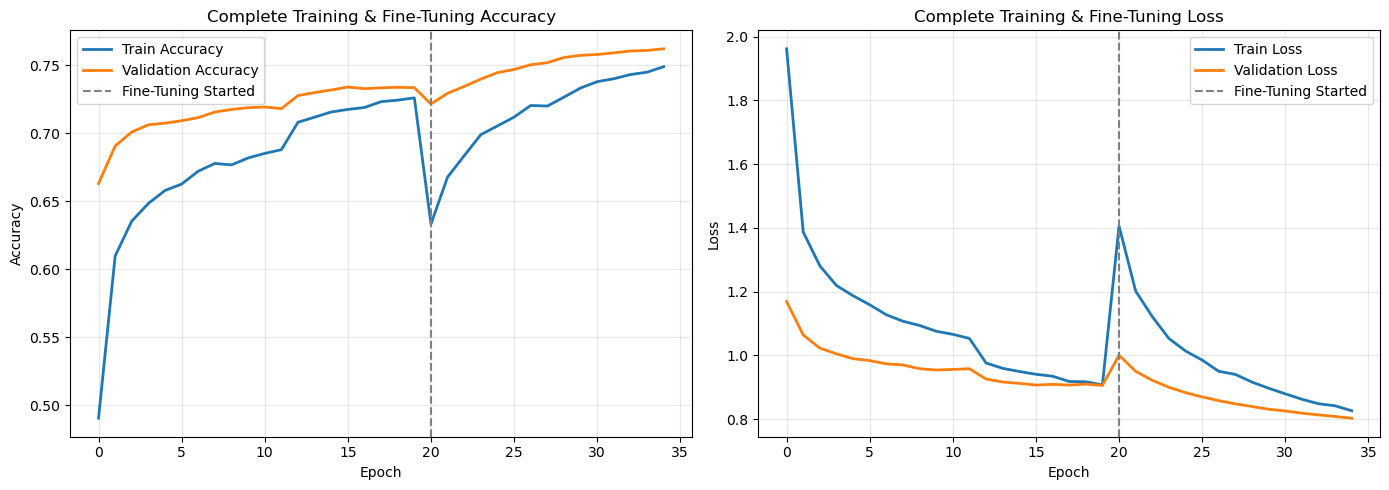

In [16]:
# Plotting Combined Training History (Phase 1 + Phase 2)
print("Plotting training metrics...")
train_acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']

train_loss = history.history['loss'] + history_finetune.history['loss']
val_loss = history.history['val_loss'] + history_finetune.history['val_loss']

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy', linewidth=2)
plt.axvline(x=len(history.history['accuracy']), color='gray', linestyle='--', label='Fine-Tuning Started')
plt.title('Complete Training & Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss', linewidth=2)
plt.plot(val_loss, label='Validation Loss', linewidth=2)
plt.axvline(x=len(history.history['loss']), color='gray', linestyle='--', label='Fine-Tuning Started')
plt.title('Complete Training & Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 4. Save the Model
model_filename = 'cifar100_efficientnet_finetuned.keras'
transfer_model.save(model_filename)
print(f"\nModel successfully saved to disk as '{model_filename}'!")